# 420 · QLoRA SFT 학습 — 실행

**3일차 2교시에 시작** · 슬라이드 86–91 · **GPU 필요 (T4 이상)**

> **진행 안내.** 이 노트북은 오래 걸립니다.

## 이 노트북의 산출물
```
artifacts/runs/<run_id>/config.json      전량 설정 (재현용)
artifacts/runs/<run_id>/history.json     손실 곡선 원본
artifacts/runs/<run_id>/loss_curve.png
artifacts/runs/<run_id>/adapter/         LoRA 어댑터 (수십 MB)
```

In [1]:
# --- 패키지 설치 (Colab) ---
# 설치 후 "런타임 다시 시작" 안내가 나오면 재시작하고, 다음 셀부터 이어서 실행한다.
!pip install -q transformers==4.57.1 datasets==4.0.0 accelerate==1.10.1 \
    peft==0.17.1 trl==0.23.0 bitsandbytes==0.47.0 tiktoken==0.11.0
!apt-get install -y fonts-nanum -qq > /dev/null   # matplotlib 한글 폰트

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/374.9 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.9/504.9 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.7/564.7 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 23.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [2]:
# --- 저장소 클론 및 루트 이동 (Colab) ---
from pathlib import Path

if not Path("common/config.py").exists():
    !git clone -q https://github.com/ironmanciti/LLM_FineTuning_Lecture.git
    %cd LLM_FineTuning_Lecture
print("저장소 루트:", Path.cwd())

from common import config as C, env, artifacts as art
env.set_seed(C.SEED)

/content/LLM_FineTuning_Lecture
저장소 루트: /content/LLM_FineTuning_Lecture


42

In [3]:
# --- Google Drive 연결: artifacts/ 영속화 (Colab) ---
# 노트북마다 런타임(VM)이 다르므로, 산출물을 Drive에 두어야 다음 노트북에서 읽을 수 있다.
import shutil
from pathlib import Path

try:
    from google.colab import drive  # Colab이 아니면 ImportError

    drive.mount("/content/drive")

    DRIVE_ART = Path("/content/drive/MyDrive/LLM_FineTuning_Lecture/artifacts")
    DRIVE_ART.mkdir(parents=True, exist_ok=True)

    local_art = Path("artifacts")
    if not local_art.is_symlink():
        if local_art.exists():  # 이미 로컬에 쓴 결과가 있으면 Drive로 이관
            shutil.copytree(local_art, DRIVE_ART, dirs_exist_ok=True)
            shutil.rmtree(local_art)
        local_art.symlink_to(DRIVE_ART)
    print("artifacts ->", local_art.resolve())
except ImportError:
    print("Colab이 아니므로 로컬 artifacts/ 를 그대로 사용합니다.")

Mounted at /content/drive
artifacts -> /content/drive/MyDrive/LLM_FineTuning_Lecture/artifacts


In [4]:
info = env.print_env()
assert info.cuda_available, "GPU 런타임이 필요합니다 (Colab: 런타임 유형 변경 > T4)."

# Colab 세션 끊김 대비 — Drive에 체크포인트를 두면 재시작 후 이어서 학습할 수 있다
USE_DRIVE = False
if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    CKPT_ROOT = "/content/drive/MyDrive/llm_ft_ckpt"
else:
    CKPT_ROOT = "./ckpt"
print("체크포인트 위치:", CKPT_ROOT)

Python 3.12.13  |  torch 2.11.0+cu128
GPU            : Tesla T4  (14.56 GB)
bf16 지원      : True
권장 dtype     : bfloat16
attention 구현 : sdpa
  [주의] T4는 FlashAttention을 지원하지 않습니다. attn_implementation='sdpa'(또는 'eager')를 사용합니다.
체크포인트 위치: ./ckpt


---
## 1. 설정 — 빈칸을 채우십시오

3일차 1교시(§3.10)에서 정한 값을 여기에 넣는다. 기본값은 T4에서 검증된 안전한 조합이다.
값을 바꾸면 **왜 바꿨는지 `RATIONALE`에 적어야 한다** — 근거 없는 설정 변경은 실험이 아니다.

In [5]:
import torch, json, time, math
from pathlib import Path

# --- 020에서 정한 값 ---
tc = art.load_json(art.token_cost_path(), default=None)
MAX_LEN = tc["recommended_max_seq_len"] if tc else C.MAX_SEQ_LEN

# --- 1교시에서 정할 값 (§3.10) ---
R              = C.LORA["r"]                    # 랭크. 8/16/32
ALPHA          = C.LORA["alpha"]                # scaling = alpha/r
DROPOUT        = C.LORA["dropout"]
TARGET_MODULES = C.LORA["target_modules"]       # "all-linear" | ["q_proj","v_proj"] 등

EPOCHS      = C.TRAIN["epochs"]
BATCH       = C.TRAIN["per_device_batch_size"]  # T4에서는 보통 1
GRAD_ACCUM  = C.TRAIN["grad_accum"]             # 유효 배치 = BATCH x GRAD_ACCUM
LR          = C.TRAIN["lr"]                     # LoRA는 전체 파인튜닝보다 큰 LR (§3.10-3)
WARMUP      = C.TRAIN["warmup_ratio"]
SCHEDULER   = C.TRAIN["lr_scheduler"]
MAX_GRAD_NORM = C.TRAIN["max_grad_norm"]        # fp16 발산 방지 (§3.11-3)
GRAD_CKPT   = C.TRAIN["gradient_checkpointing"] # 시간과 메모리의 교환 (§3.8-3)

RATIONALE = {
    "r": "16 — 형식 교정 위주이므로 큰 랭크가 필요하지 않다. 32와 비교 실험은 선택 과제.",
    "target_modules": "all-linear — attention만보다 효과가 큰 경향. VRAM 여유가 있어 채택.",
    "lr": "2e-4 — LoRA 관례 범위(1e-4~3e-4). 발산하면 1e-4로 낮춘다.",
    "epochs": "2 — 2000건 규모에서 3 epoch은 과적합 위험(§3.10-3).",
    "grad_accum": "8 — T4에서 batch=1이 강제되므로 유효 배치 8로 보정.",
}

RUN_ID = f"r{R}a{ALPHA}_{TARGET_MODULES if isinstance(TARGET_MODULES,str) else 'sel'}_" \
         f"lr{LR:g}_ep{EPOCHS}_len{MAX_LEN}"

# 산출물 경로를 여기서 미리 만든다.
# (그림 셀 안에서 만들면, 폰트 오류로 그림이 실패했을 때 어댑터 저장까지 못 하게 된다)
rd = art.run_dir(RUN_ID)

print("run_id:", RUN_ID)
print("산출물 경로:", rd)
print(f"유효 배치: {BATCH} x {GRAD_ACCUM} = {BATCH*GRAD_ACCUM}")

run_id: r16a32_all-linear_lr0.0002_ep2_len768
산출물 경로: /content/LLM_FineTuning_Lecture/artifacts/runs/r16a32_all-linear_lr0.0002_ep2_len768
유효 배치: 1 x 8 = 8


---
## 2. 데이터 로드 — `410`의 산출물

In [6]:
train_rows = art.load_jsonl(art.data_path("train.jsonl"))
eval_rows = art.load_jsonl(art.data_path("eval.jsonl"))
assert train_rows, "artifacts/data/train.jsonl 이 없습니다. 410을 먼저 실행하십시오."
print(f"train {len(train_rows)}건 / eval {len(eval_rows)}건")

data_report = art.load_json(art.data_path("data_report.json"), default={})
print("누수 검증:", data_report.get("leakage_verified_zero"))
print("max_seq_len 출처:", data_report.get("max_seq_len_source"))

train 2000건 / eval 200건
누수 검증: True
max_seq_len 출처: config 기본값


---
## 3. 4bit 모델 로드 (QLoRA)

베이스 가중치는 **동결**되고 학습되는 것은 fp16 LoRA 어댑터뿐이다. 그래서 베이스를
4bit로 낮춰도 학습이 된다(2일차 §3.8-1).

In [7]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

DTYPE = env.pick_dtype()
if not info.supports_bf16:
    print("[주의] bf16 미지원 GPU입니다. fp16으로 학습합니다.")
    print("       loss가 NaN이 되면 (1) LR을 절반으로 (2) max_grad_norm 확인 (3) warmup 확대")

tok = AutoTokenizer.from_pretrained(C.MODEL_ID)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
tok.padding_side = "right"

bnb = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=DTYPE,
)

with env.vram_probe("4bit 베이스 로드") as p:
    model = AutoModelForCausalLM.from_pretrained(
        C.MODEL_ID, quantization_config=bnb, device_map={"": 0},
        attn_implementation=info.attn_implementation,
    )
vram_base = p.result
model.config.use_cache = False          # gradient checkpointing과 충돌하므로 학습 중엔 끈다

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:212: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

[VRAM] 4bit 베이스 로드: +0.426 GB (피크 0.507 GB)


In [8]:
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=GRAD_CKPT)

lora_cfg = LoraConfig(
    r=R, lora_alpha=ALPHA, lora_dropout=DROPOUT,
    target_modules=TARGET_MODULES, bias="none", task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_cfg)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"학습 파라미터 : {trainable:,}  ({100*trainable/total:.3f}%)")
print(f"전체 파라미터 : {total:,}")
print(f"scaling       : alpha/r = {ALPHA}/{R} = {ALPHA/R}")
print(f"어댑터 예상 크기: {trainable*2/1024**2:.1f} MB (fp16)\n")
model.print_trainable_parameters()

# 어느 모듈에 붙었는지 확인 — all-linear의 실제 동작은 peft 버전마다 다르다
hit = sorted({n.split(".lora_A")[0].split(".")[-1] for n, _ in model.named_parameters() if "lora_A" in n})
print("\nLoRA가 붙은 모듈:", hit)

학습 파라미터 : 8,798,208  (2.716%)
전체 파라미터 : 323,917,696
scaling       : alpha/r = 32/16 = 2.0
어댑터 예상 크기: 16.8 MB (fp16)

trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497

LoRA가 붙은 모듈: ['down_proj', 'gate_proj', 'k_proj', 'o_proj', 'q_proj', 'up_proj', 'v_proj']


---
## 4. 데이터셋 — 토크나이즈와 손실 마스킹

`410`에서 검증한 마스킹 로직을 그대로 쓴다. 여기서 다른 코드를 쓰면 `410`의 검증이 무효가 된다.

In [9]:
from torch.utils.data import Dataset
from common import chat

class SFTDataset(Dataset):
    def __init__(self, rows, tokenizer, max_len):
        self.rows, self.tok, self.max_len = rows, tokenizer, max_len
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, i):
        r = self.rows[i]
        msgs = chat.build_messages(r["question"], system=r["system"], context=r["context"])
        return chat.build_example(self.tok, msgs, r["target"],
                                  max_len=self.max_len, mask_prompt=True)

def collate(batch):
    return chat.pad_batch(batch, tok.pad_token_id)

train_ds = SFTDataset(train_rows, tok, MAX_LEN)
# eval은 손실 관측용으로만 일부 사용한다. 태스크 지표는 430에서 별도로 낸다.
eval_ds = SFTDataset(eval_rows[:64], tok, MAX_LEN)

b = collate([train_ds[0], train_ds[1]])
print({k: tuple(v.shape) for k, v in b.items()})
n_ign = int((b["labels"] == -100).sum())
print(f"마스킹된 토큰: {n_ign} / {b['labels'].numel()} ({100*n_ign/b['labels'].numel():.1f}%)")
assert n_ign > 0, "마스킹이 적용되지 않았습니다"

{'input_ids': (2, 661), 'labels': (2, 661), 'attention_mask': (2, 661)}
마스킹된 토큰: 1189 / 1322 (89.9%)


---
## 5. 학습

여기서는 `trl.SFTTrainer`가 아니라 `transformers.Trainer`를 쓴다 — 우리가 직접 만든
`input_ids`/`labels`를 그대로 쓰기 때문이다. `trl.SFTTrainer`는 prompt-completion 형식 데이터에서 자동으로 마스킹을 만들어 주지만,
**손실 마스킹을 눈으로 확인하는 것이 이 과정의 학습목표**이므로 명시적 경로를 택했다.
(`SFTTrainer` 사용법은 아래 부록 셀에 비교로 남겨 두었다.)

In [10]:
from transformers import Trainer, TrainingArguments

steps_per_epoch = math.ceil(len(train_ds) / (BATCH * GRAD_ACCUM))
total_steps = steps_per_epoch * EPOCHS
print(f"epoch당 {steps_per_epoch} step x {EPOCHS} epoch = 총 {total_steps} step")

args = TrainingArguments(
    output_dir=f"{CKPT_ROOT}/{RUN_ID}",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    lr_scheduler_type=SCHEDULER,
    warmup_ratio=WARMUP,
    max_grad_norm=MAX_GRAD_NORM,
    fp16=not info.supports_bf16,
    bf16=info.supports_bf16,
    gradient_checkpointing=GRAD_CKPT,
    gradient_checkpointing_kwargs={"use_reentrant": False} if GRAD_CKPT else None,
    logging_steps=C.TRAIN["logging_steps"],
    eval_strategy="steps",
    eval_steps=C.TRAIN["eval_steps"],
    per_device_eval_batch_size=1,
    save_strategy="steps",
    save_steps=C.TRAIN["save_steps"],
    save_total_limit=2,
    optim="paged_adamw_8bit",     # 옵티마이저 상태를 페이징 (§3.8-3)
    report_to="none",
    seed=C.SEED,
    data_seed=C.SEED,
)

trainer = Trainer(model=model, args=args, train_dataset=train_ds,
                  eval_dataset=eval_ds, data_collator=collate)

epoch당 250 step x 2 epoch = 총 500 step


In [11]:
# 학습 시작. T4 / 0.5B / 2000건 / 2epoch 기준 대략 15~30분.
# 이 셀을 실행한 뒤 3교시 강의로 넘어가십시오.
env.vram_reset()
t0 = time.perf_counter()

RESUME = None      # 세션이 끊겼다면 f"{CKPT_ROOT}/{RUN_ID}/checkpoint-XXX" 를 넣고 재실행
result = trainer.train(resume_from_checkpoint=RESUME)

elapsed = time.perf_counter() - t0
peak = env.vram_gb()["peak_gb"]
print(f"\n학습 완료: {elapsed/60:.1f}분 / 피크 VRAM {peak} GB")
print(f"최종 train loss: {result.training_loss:.4f}")

Step,Training Loss,Validation Loss
50,0.078100,0.078050
100,0.056400,0.058308
150,0.063300,0.060970
200,0.052000,0.057636
250,0.033600,0.053710
300,0.018500,0.054361
350,0.020100,0.053156
400,0.015500,0.051942
450,0.015800,0.051932
500,0.012000,0.051776



학습 완료: 78.4분 / 피크 VRAM 2.4 GB
최종 train loss: 0.0420


---
## 6. 어댑터·설정·곡선 저장

**설정을 적어두지 않은 실행은 실험이 아니다**(§3.10-5). 여기서 저장하는 것이
3일차 3교시 진단과 8교시 리포트의 입력이 된다.

> **순서 주의.** 어댑터를 **가장 먼저** 저장한다. 그림 그리기가 폰트 문제로 실패해도
> 학습 결과는 이미 디스크에 있어야 한다.

In [12]:
model.save_pretrained(str(rd / "adapter"))
tok.save_pretrained(str(rd / "adapter"))

size_mb = sum(f.stat().st_size for f in (rd / "adapter").rglob("*") if f.is_file()) / 1024**2
print(f"어댑터 저장: {rd/'adapter'}  ({size_mb:.1f} MB)")
print(f"베이스 모델 전체를 저장하면 수 GB다. 어댑터만 {size_mb:.0f} MB — 이것이 PEFT의 실무 이점.")

어댑터 저장: /content/LLM_FineTuning_Lecture/artifacts/runs/r16a32_all-linear_lr0.0002_ep2_len768/adapter  (48.8 MB)
베이스 모델 전체를 저장하면 수 GB다. 어댑터만 49 MB — 이것이 PEFT의 실무 이점.


In [13]:
import transformers, peft
try:
    import bitsandbytes as bnb_mod; bnb_ver = bnb_mod.__version__
except Exception:
    bnb_ver = "unknown"

cfg_dump = {
    "run_id": RUN_ID,
    "model_id": C.MODEL_ID,
    "seed": C.SEED,
    "max_seq_len": MAX_LEN,
    "max_seq_len_source": data_report.get("max_seq_len_source"),
    "quantization": {"load_in_4bit": True, "quant_type": "nf4",
                     "double_quant": True, "compute_dtype": str(DTYPE)},
    "lora": {"r": R, "alpha": ALPHA, "dropout": DROPOUT,
             "target_modules": TARGET_MODULES, "modules_hit": hit,
             "trainable_params": int(trainable), "trainable_pct": round(100*trainable/total, 4)},
    "train": {"epochs": EPOCHS, "batch": BATCH, "grad_accum": GRAD_ACCUM,
              "effective_batch": BATCH*GRAD_ACCUM, "lr": LR, "scheduler": SCHEDULER,
              "warmup_ratio": WARMUP, "max_grad_norm": MAX_GRAD_NORM,
              "gradient_checkpointing": GRAD_CKPT, "optim": args.optim,
              "fp16": bool(args.fp16), "bf16": bool(args.bf16),
              "total_steps": total_steps},
    "data": {"n_train": len(train_rows), "n_eval_for_loss": len(eval_ds),
             "dataset": C.DATASET_ID},
    "result": {"final_train_loss": float(result.training_loss),
               "elapsed_min": round(elapsed/60, 2), "peak_vram_gb": peak,
               "base_load_vram_gb": vram_base["delta_gb"]},
    "env": info.to_dict(),
    "versions": {"transformers": transformers.__version__, "peft": peft.__version__,
                 "torch": torch.__version__, "bitsandbytes": bnb_ver},
    "rationale": RATIONALE,
}
art.save_json(rd / "config.json", cfg_dump)
print("저장:", rd / "config.json")
print(json.dumps({k: cfg_dump[k] for k in ["run_id", "result"]}, ensure_ascii=False, indent=2))

저장: /content/LLM_FineTuning_Lecture/artifacts/runs/r16a32_all-linear_lr0.0002_ep2_len768/config.json
{
  "run_id": "r16a32_all-linear_lr0.0002_ep2_len768",
  "result": {
    "final_train_loss": 0.04200217258930206,
    "elapsed_min": 78.41,
    "peak_vram_gb": 2.4,
    "base_load_vram_gb": 0.426
  }
}


### 손실 곡선

곡선 원본(`history.json`)을 먼저 저장하고 그림을 그린다. 그림은 실패해도 원본이 남는다.

저장: /content/LLM_FineTuning_Lecture/artifacts/runs/r16a32_all-linear_lr0.0002_ep2_len768/history.json


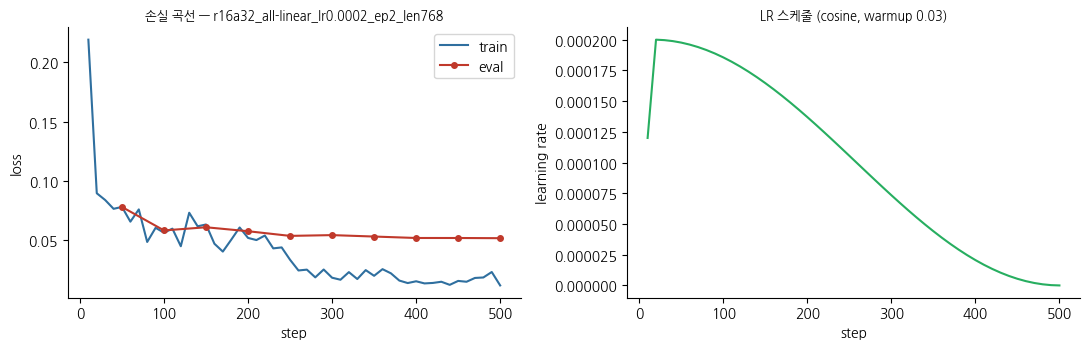

저장: /content/LLM_FineTuning_Lecture/artifacts/runs/r16a32_all-linear_lr0.0002_ep2_len768/loss_curve.png

3교시에서 배운 4패턴 중 어디에 해당하는지 판정하십시오 (§3.11-1).


In [14]:
log = trainer.state.log_history
tr = [(e["step"], e["loss"]) for e in log if "loss" in e and "eval_loss" not in e]
ev = [(e["step"], e["eval_loss"]) for e in log if "eval_loss" in e]
lrs = [(e["step"], e["learning_rate"]) for e in log if "learning_rate" in e]
art.save_json(rd / "history.json", {"train": tr, "eval": ev, "lr": lrs, "log_history": log})
print("저장:", rd / "history.json")

try:
    import matplotlib.pyplot as plt, matplotlib
    matplotlib.font_manager.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
    matplotlib.rcParams["font.family"] = "NanumGothic"
    matplotlib.rcParams["axes.unicode_minus"] = False

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    if tr:
        axes[0].plot(*zip(*tr), label="train", color="#2f6f9f")
    if ev:
        axes[0].plot(*zip(*ev), "o-", label="eval", color="#c0392b", ms=4)
    axes[0].set_xlabel("step"); axes[0].set_ylabel("loss")
    axes[0].set_title(f"손실 곡선 — {RUN_ID}", fontsize=9); axes[0].legend()
    if lrs:
        axes[1].plot(*zip(*lrs), color="#27ae60")
    axes[1].set_xlabel("step"); axes[1].set_ylabel("learning rate")
    axes[1].set_title(f"LR 스케줄 ({SCHEDULER}, warmup {WARMUP})", fontsize=9)
    for ax in axes:
        ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(rd / "loss_curve.png", dpi=140, bbox_inches="tight")
    plt.show()
    print("저장:", rd / "loss_curve.png")
except Exception as e:
    print(f"[그림 실패] {type(e).__name__}: {e}")
    print("  history.json 은 저장되었으므로 나중에 다시 그릴 수 있습니다.")
    print("  첫 설치 셀(fonts-nanum 포함)을 실행했는지 확인하십시오.")

print("\n3교시에서 배운 4패턴 중 어디에 해당하는지 판정하십시오 (§3.11-1).")

---
## 7. 눈으로 확인 — 학습 전후 응답 1건

정식 평가는 `430`에서 한다. 여기서는 **뭔가 배운 것 같은가**만 빠르게 본다.

In [15]:
model.config.use_cache = True
model.eval()

def answer(row, use_adapter=True):
    msgs = chat.build_messages(row["question"], system=row["system"], context=row["context"])
    prompt = chat.render_prompt(tok, msgs)
    ins = tok(prompt, return_tensors="pt").to(model.device)
    ctx = torch.no_grad()
    with ctx:
        if use_adapter:
            o = model.generate(**ins, pad_token_id=tok.pad_token_id, **C.GEN_EVAL)
        else:
            with model.disable_adapter():
                o = model.generate(**ins, pad_token_id=tok.pad_token_id, **C.GEN_EVAL)
    return tok.decode(o[0][ins["input_ids"].shape[1]:], skip_special_tokens=True).strip()

for row in eval_rows[:3]:
    print("=" * 74)
    print("질문   :", row["question"])
    print("정답   :", row["answer"])
    print("[베이스]", answer(row, use_adapter=False)[:220])
    print("[학습후]", answer(row, use_adapter=True)[:220])

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


질문   : 임종석이 여의도 농민 폭력 시위를 주도한 혐의로 지명수배 된 날은?
정답   : 1989년 2월 15일


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[베이스] 1989년 2월 15일
[학습후] {"answer": "1989년 2월 15일", "evidence": "1989년 2월 15일 여의도 농민 폭력 시위를 주도한 혐의(폭력행위등처벌에관한법률위반)으로 지명수배되었다."}
질문   : 1989년 6월 30일 평양축전에 대표로 파견 된 인물은?
정답   : 임수경
[베이스] 1989년 6월 30일 평양축전에 대표로 파견된 인물은 임수경입니다.
[학습후] {"answer": "임수경", "evidence": "같은 해 6월 30일 평양축전에 임수경을 대표로 파견하여 국가보안법위반 혐의가 추가되었다."}
질문   : 임종석이 여의도 농민 폭력 시위를 주도한 혐의로 지명수배된 연도는?
정답   : 1989년
[베이스] 1989년 2월 15일
[학습후] {"answer": "1989년", "evidence": "1989년 2월 15일 여의도 농민 폭력 시위를 주도한 혐의(폭력행위등처벌에관한법률위반)으로 지명수배되었다."}


### 무엇을 보아야 하는가

- **JSON 형식이 잡혔는가** — 베이스는 설명을 붙이거나 형식을 어기는 경우가 많다.
  0.5B에서 가장 뚜렷하게 개선되는 지점이다(§3.12-4).
- **정답 내용이 맞는가** — 크게 안 좋아질 수 있다. **그것이 슬라이드 90의 메시지이며,
  실습 실패가 아니다.** `430`에서 정량으로 확인한다.
- **응답이 제대로 끝나는가** — 안 끝나면 EOS 학습 또는 길이 잘림 문제다(`410` 점검 재확인).

---
## 부록 A · `trl.SFTTrainer`로 같은 일 하기

실무에서는 아래처럼 짧게 쓴다. 마스킹을 라이브러리가 처리하므로 **눈으로 확인하기 어렵다** —
그래서 본 실습은 명시적 경로를 택했다. 원리를 안 뒤에는 이쪽을 쓰는 것이 맞다.

In [16]:
# 실행하지 않는다. 비교용 코드다.
SFT_TRAINER_EXAMPLE = r"""
from trl import SFTTrainer, SFTConfig
from datasets import Dataset

# prompt-completion 형식: SFTTrainer가 chat template 적용과
# 프롬프트 마스킹(completion_only_loss=True 기본값)을 알아서 처리한다.
# 이것이 우리가 4절에서 직접 한 마스킹에 해당한다.
def to_prompt_completion(r):
    return {
        "prompt": [
            {"role": "system", "content": r["system"]},
            {"role": "user", "content": r["context"] + "\n\n" + r["question"]},
        ],
        "completion": [{"role": "assistant", "content": r["target"]}],
    }

ds = Dataset.from_list([to_prompt_completion(r) for r in train_rows])

trainer = SFTTrainer(
    model=model,
    train_dataset=ds,
    args=SFTConfig(
        output_dir="out", max_length=MAX_LEN, packing=False,
        num_train_epochs=EPOCHS, per_device_train_batch_size=BATCH,
        gradient_accumulation_steps=GRAD_ACCUM, learning_rate=LR,
    ),
)
trainer.train()
"""
print(SFT_TRAINER_EXAMPLE)
print("주의: 마스킹이 자동이라고 해서 늘 옳게 되는 것은 아니다. 학습 후 손실이")
print("      비정상적으로 낮으면 프롬프트까지 학습되고 있지 않은지 의심할 것.")
print("참고: 구버전 trl(0.9대)의 max_seq_length 인자는 max_length로 바뀌었고,")
print("      DataCollatorForCompletionOnlyLM은 최신 trl에서 제거되었다.")


from trl import SFTTrainer, SFTConfig
from datasets import Dataset

# prompt-completion 형식: SFTTrainer가 chat template 적용과
# 프롬프트 마스킹(completion_only_loss=True 기본값)을 알아서 처리한다.
# 이것이 우리가 4절에서 직접 한 마스킹에 해당한다.
def to_prompt_completion(r):
    return {
        "prompt": [
            {"role": "system", "content": r["system"]},
            {"role": "user", "content": r["context"] + "\n\n" + r["question"]},
        ],
        "completion": [{"role": "assistant", "content": r["target"]}],
    }

ds = Dataset.from_list([to_prompt_completion(r) for r in train_rows])

trainer = SFTTrainer(
    model=model,
    train_dataset=ds,
    args=SFTConfig(
        output_dir="out", max_length=MAX_LEN, packing=False,
        num_train_epochs=EPOCHS, per_device_train_batch_size=BATCH,
        gradient_accumulation_steps=GRAD_ACCUM, learning_rate=LR,
    ),
)
trainer.train()

주의: 마스킹이 자동이라고 해서 늘 옳게 되는 것은 아니다. 학습 후 손실이
      비정상적으로 낮으면 프롬프트까지 학습되고 있지 않은지 의심할 것.
참고: 구버전 trl(0.9대)의 max_seq_length 인자는 max_lengt

---
## 부록 B · 학습이 실패했을 때 (§3.11-3)

| 증상 | 원인 후보 | 조치 순서 |
|---|---|---|
| **OOM** | 시퀀스·배치·랭크 | `MAX_LEN` ↓ → `BATCH` ↓ → `GRAD_CKPT=True` → `R` ↓ |
| **loss = NaN** | fp16 오버플로 / LR 과대 / 전량 마스킹 | `LR` 절반 → `MAX_GRAD_NORM` 확인 → `410`의 마스킹 재점검 |
| **loss가 안 내려감** | LR 과소 / 랭크 부족 / 마스킹 오류 | `LR` 2~3배 → `R` ↑ → 마스킹 비율 확인 |
| **eval loss만 반등** | 과적합 | `EPOCHS` ↓ → 데이터 ↑ → `DROPOUT` ↑ |
| **spike 후 발산** | warmup 부족 | `WARMUP` 0.03 → 0.1 |

아래 셀은 실패 사례를 기록해 둔다. 실패도 실험 결과다.

In [17]:
FAILURE_LOG = [
    # {"attempt": 1, "changed": "R=32, MAX_LEN=1024", "symptom": "OOM at step 12",
    #  "action": "MAX_LEN 768로 하향", "result": "정상 학습"},
]
if FAILURE_LOG:
    art.save_json(rd / "failure_log.json", FAILURE_LOG)
    print(f"{len(FAILURE_LOG)}건 기록")
else:
    print("실패 없이 완주한 경우 비워 두어도 됩니다.")
print("\n다음: 430에서 학습 전후를 동일 프로토콜로 채점합니다.")
print("run_id 를 기억하십시오:", RUN_ID)

실패 없이 완주한 경우 비워 두어도 됩니다.

다음: 430에서 학습 전후를 동일 프로토콜로 채점합니다.
run_id 를 기억하십시오: r16a32_all-linear_lr0.0002_ep2_len768
